## Patient 1 Analysis

In [97]:
import scipy.io

data_P1_pre_training = scipy.io.loadmat(r"C:\Users\rodri\OneDrive\Documentos\g.tec hackaton\Hackaton_Rehab_Data_Analysis\stroke-rehab\P1_pre_training.mat")
data_P1_pre_test = scipy.io.loadmat(r"C:\Users\rodri\OneDrive\Documentos\g.tec hackaton\Hackaton_Rehab_Data_Analysis\stroke-rehab\P1_pre_test.mat")

In [98]:
print(data_P1_pre_training.keys())
print(data_P1_pre_training["fs"])

trig_pre_training = data_P1_pre_training['trig']
y_pre_training = data_P1_pre_training['y']

print("trig shape:", trig_pre_training.shape)
print("y shape:", y_pre_training.shape)
print(data_P1_pre_training["__globals__"])

dict_keys(['__header__', '__version__', '__globals__', 'y', 'trig', 'fs'])
[[256]]
trig shape: (1, 271816)
y shape: (271816, 16)
[]


256


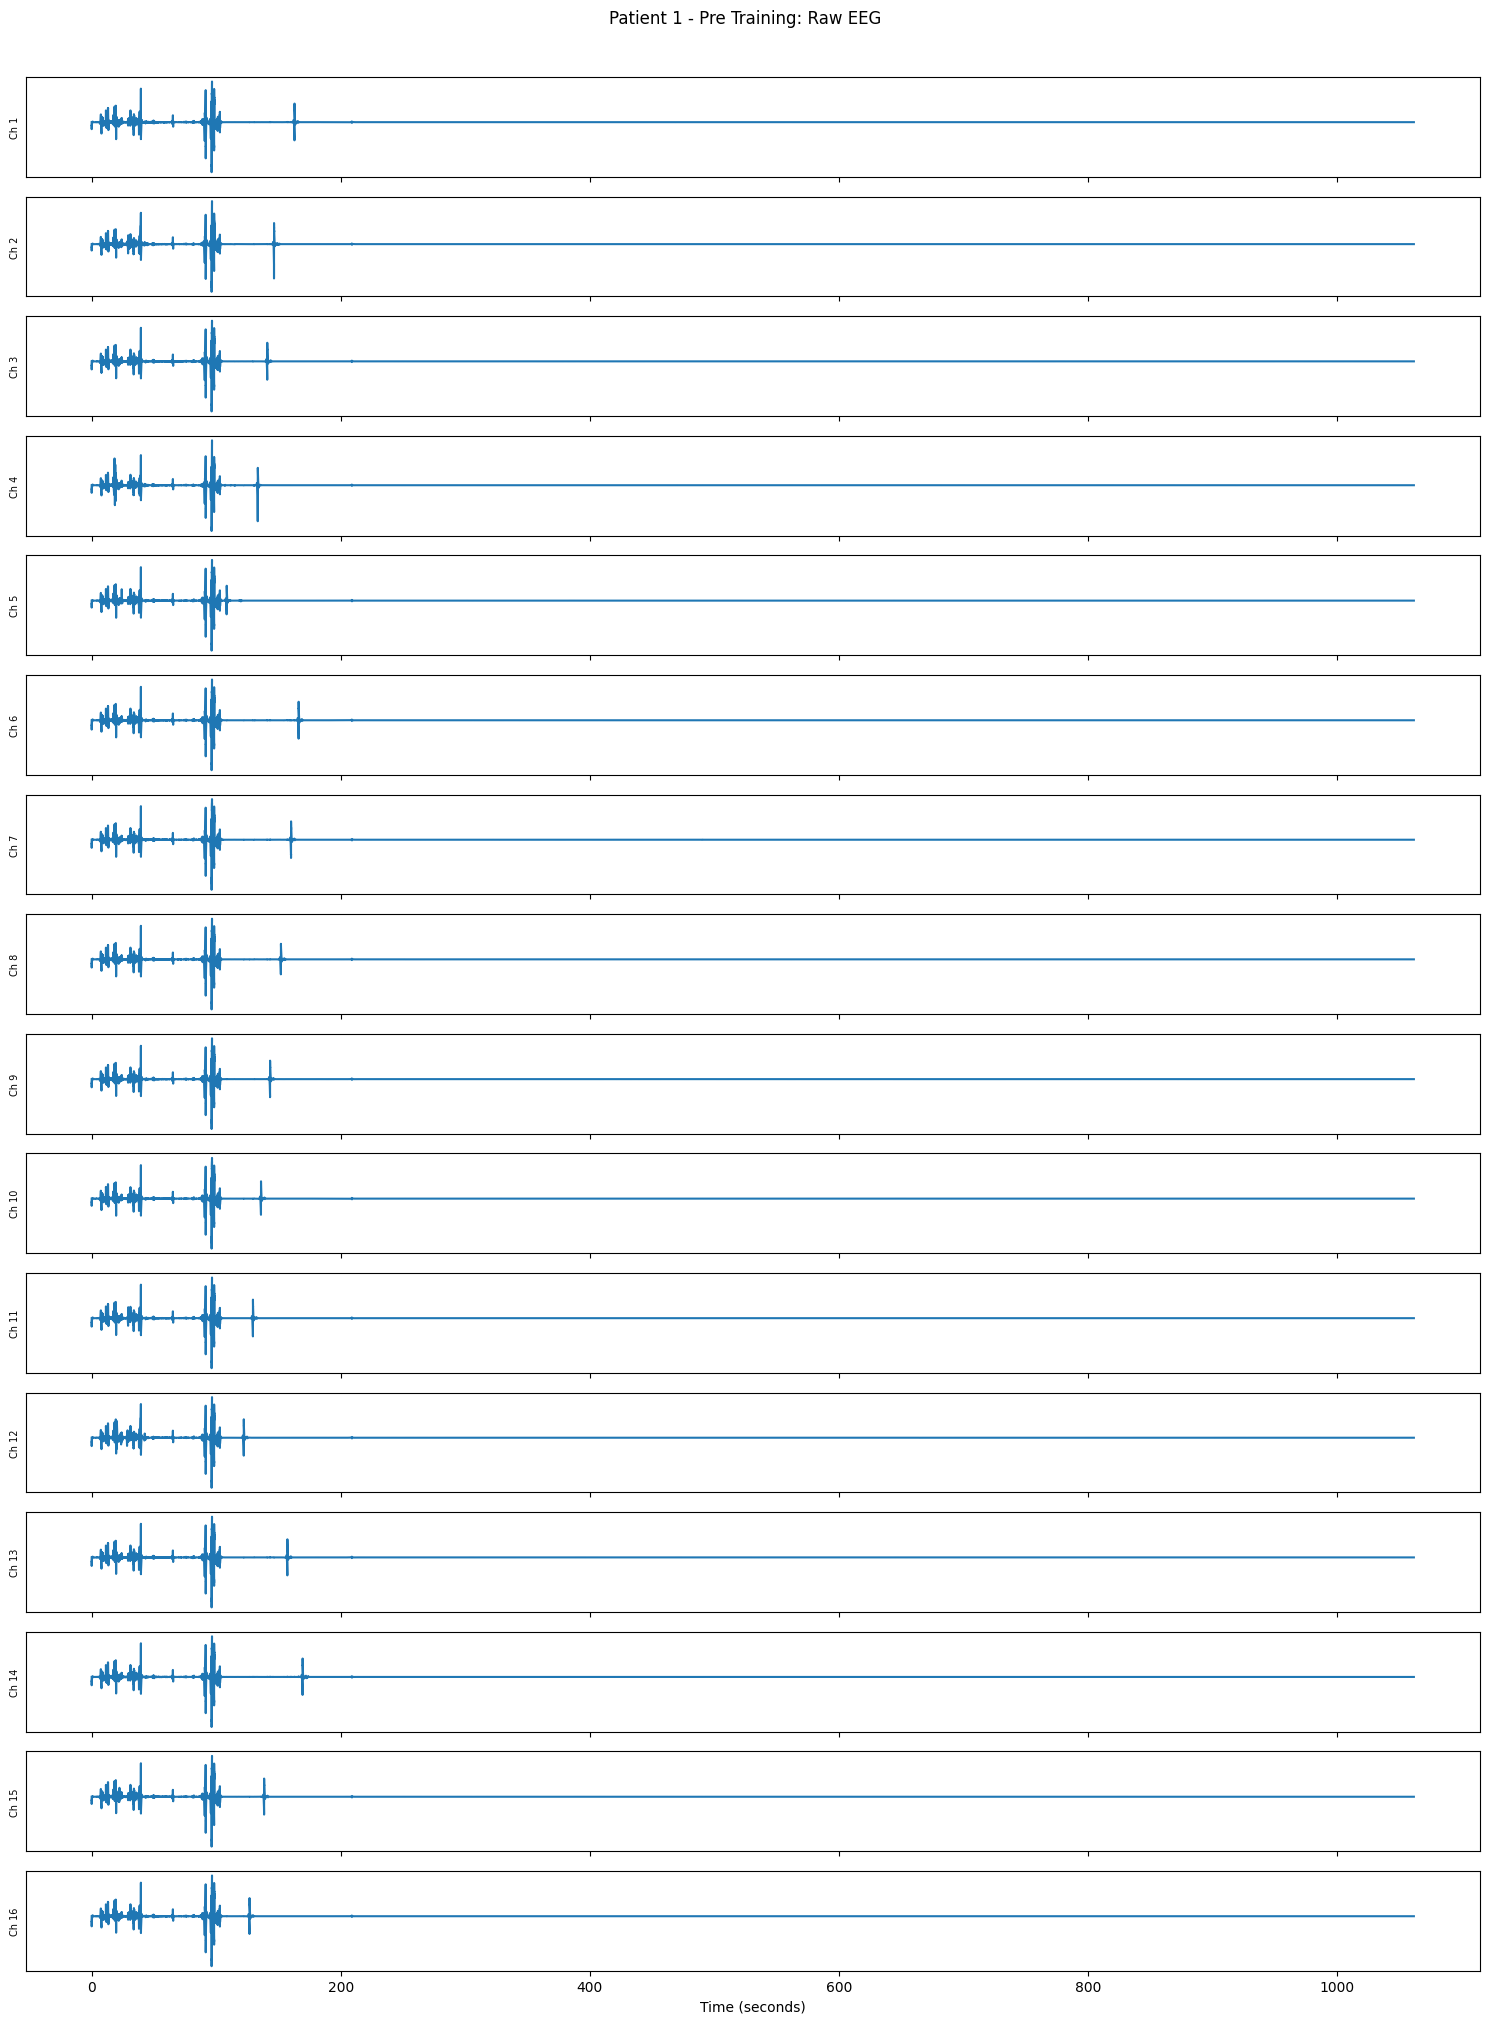

Plot saved!


In [99]:
import matplotlib.pyplot as plt
import numpy as np

fs = data_P1_pre_training["fs"][0][0] 
print(fs)
t = np.arange(y_pre_training.shape[0]) / fs
t = t.flatten()  # Flatten the time array to 1D

fig, axes = plt.subplots(16, 1, figsize=(15, 20), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(t, y_pre_training[:, i])
    ax.set_ylabel(f'Ch {i+1}', fontsize=7)
    ax.set_yticks([])

plt.xlabel('Time (seconds)')
plt.suptitle('Patient 1 - Pre Training: Raw EEG', y=1.01)
plt.tight_layout()
plt.savefig('P1_raw_eeg.png')
plt.show()
print("Plot saved!")



## Filtering

In [100]:
from scipy.signal import iirnotch, filtfilt
from scipy.signal import butter

def bandpass_filter(data, fs, lowcut, highcut, order):
    nyq = 0.5 * fs
    low = lowcut / nyq #the filter works in a normalized frequency range (0 to 1), where 1 corresponds to the Nyquist frequency
    high = highcut / nyq

    b,a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data, axis=0)

def notch_filter(data, fs, notch_freq, quality_factor=30):
    b, a = iirnotch(notch_freq, quality_factor, fs)
    return filtfilt(b, a, data, axis=0)

def trim_data(data, fs, start_time):
    start_sample = int(start_time * fs)
    return data[start_sample:, :]

def get_trigger_onsets(trig, fs):
    trig_1d = trig.flatten()
    onsets = np.where((trig_1d[1:] != 0) & (trig_1d[:-1] == 0))[0] + 1
    
    onset_times = onsets / fs
    return onset_times

In [101]:
trigger_events_time = get_trigger_onsets(trig_pre_training, fs)
print(trigger_events_time)

[ 257.1796875   266.84375     276.4375      286.03125     295.65625
  304.76171875  314.875       324.34375     334.1171875   343.78125
  353.375       362.9375      372.5234375   382.15625     391.75
  401.4375      410.9296875   420.58203125  430.15625     439.8125
  449.375       458.9375      468.5         478.15625     487.6875
  497.25        506.828125    516.453125    526.15625     535.78125
  545.40625     556.3125      565.82421875  575.53125     585.09375
  594.78125     604.40625     614.          623.6875      633.16015625
  674.53125     684.09375     693.65625     703.26171875  712.92578125
  723.125       732.71875     742.3125      751.90625     761.4375
  771.0625      780.625       790.28125     799.80859375  810.71875
  820.3125      829.85546875  839.53125     849.1875      858.75
  868.40625     877.875       887.53125     898.1875      907.78125
  917.375       926.8515625   936.53125     946.15625     955.6875
  965.2578125   974.96875     984.625       994.1875

In [ ]:
y_pre_training = trim_data(y_pre_training, fs, start_time=255)

trig_vertical = trig_pre_training.T
trig_trimmed = trim_data(trig_vertical, fs, start_time=255)

trig_trimmed = trig_trimmed.T

print("Trimmed y shape:", y_pre_training.shape)
print("Trimmed trig shape:", trig_trimmed.shape)

y_pre_training_filtered = notch_filter(y_pre_training, fs, notch_freq=50)  # Remove 50 Hz powerline noise
y_pre_training_filtered = notch_filter(y_pre_training, fs, notch_freq=60)  # Remove 60 Hz powerline noise
y_pre_training_filtered = bandpass_filter(y_pre_training_filtered, fs, lowcut=1, highcut=30, order=4)  # Keep frequencies between 1 and 30 Hz

np.savez('P1_PRE_training_cleaned.npz', 
         data=y_pre_training_filtered, 
         trig=trig_trimmed) # Make sure triggers are trimmed too!

print("Data saved as P1_PRE_training_cleaned.npz")

Trimmed y shape: (141256, 16)
Trimmed trig shape: (206536, 1)
Data saved as P1_PRE_training_cleaned.npz


Total duration in array: 806.77734375 seconds
Data shape: (206536, 16)


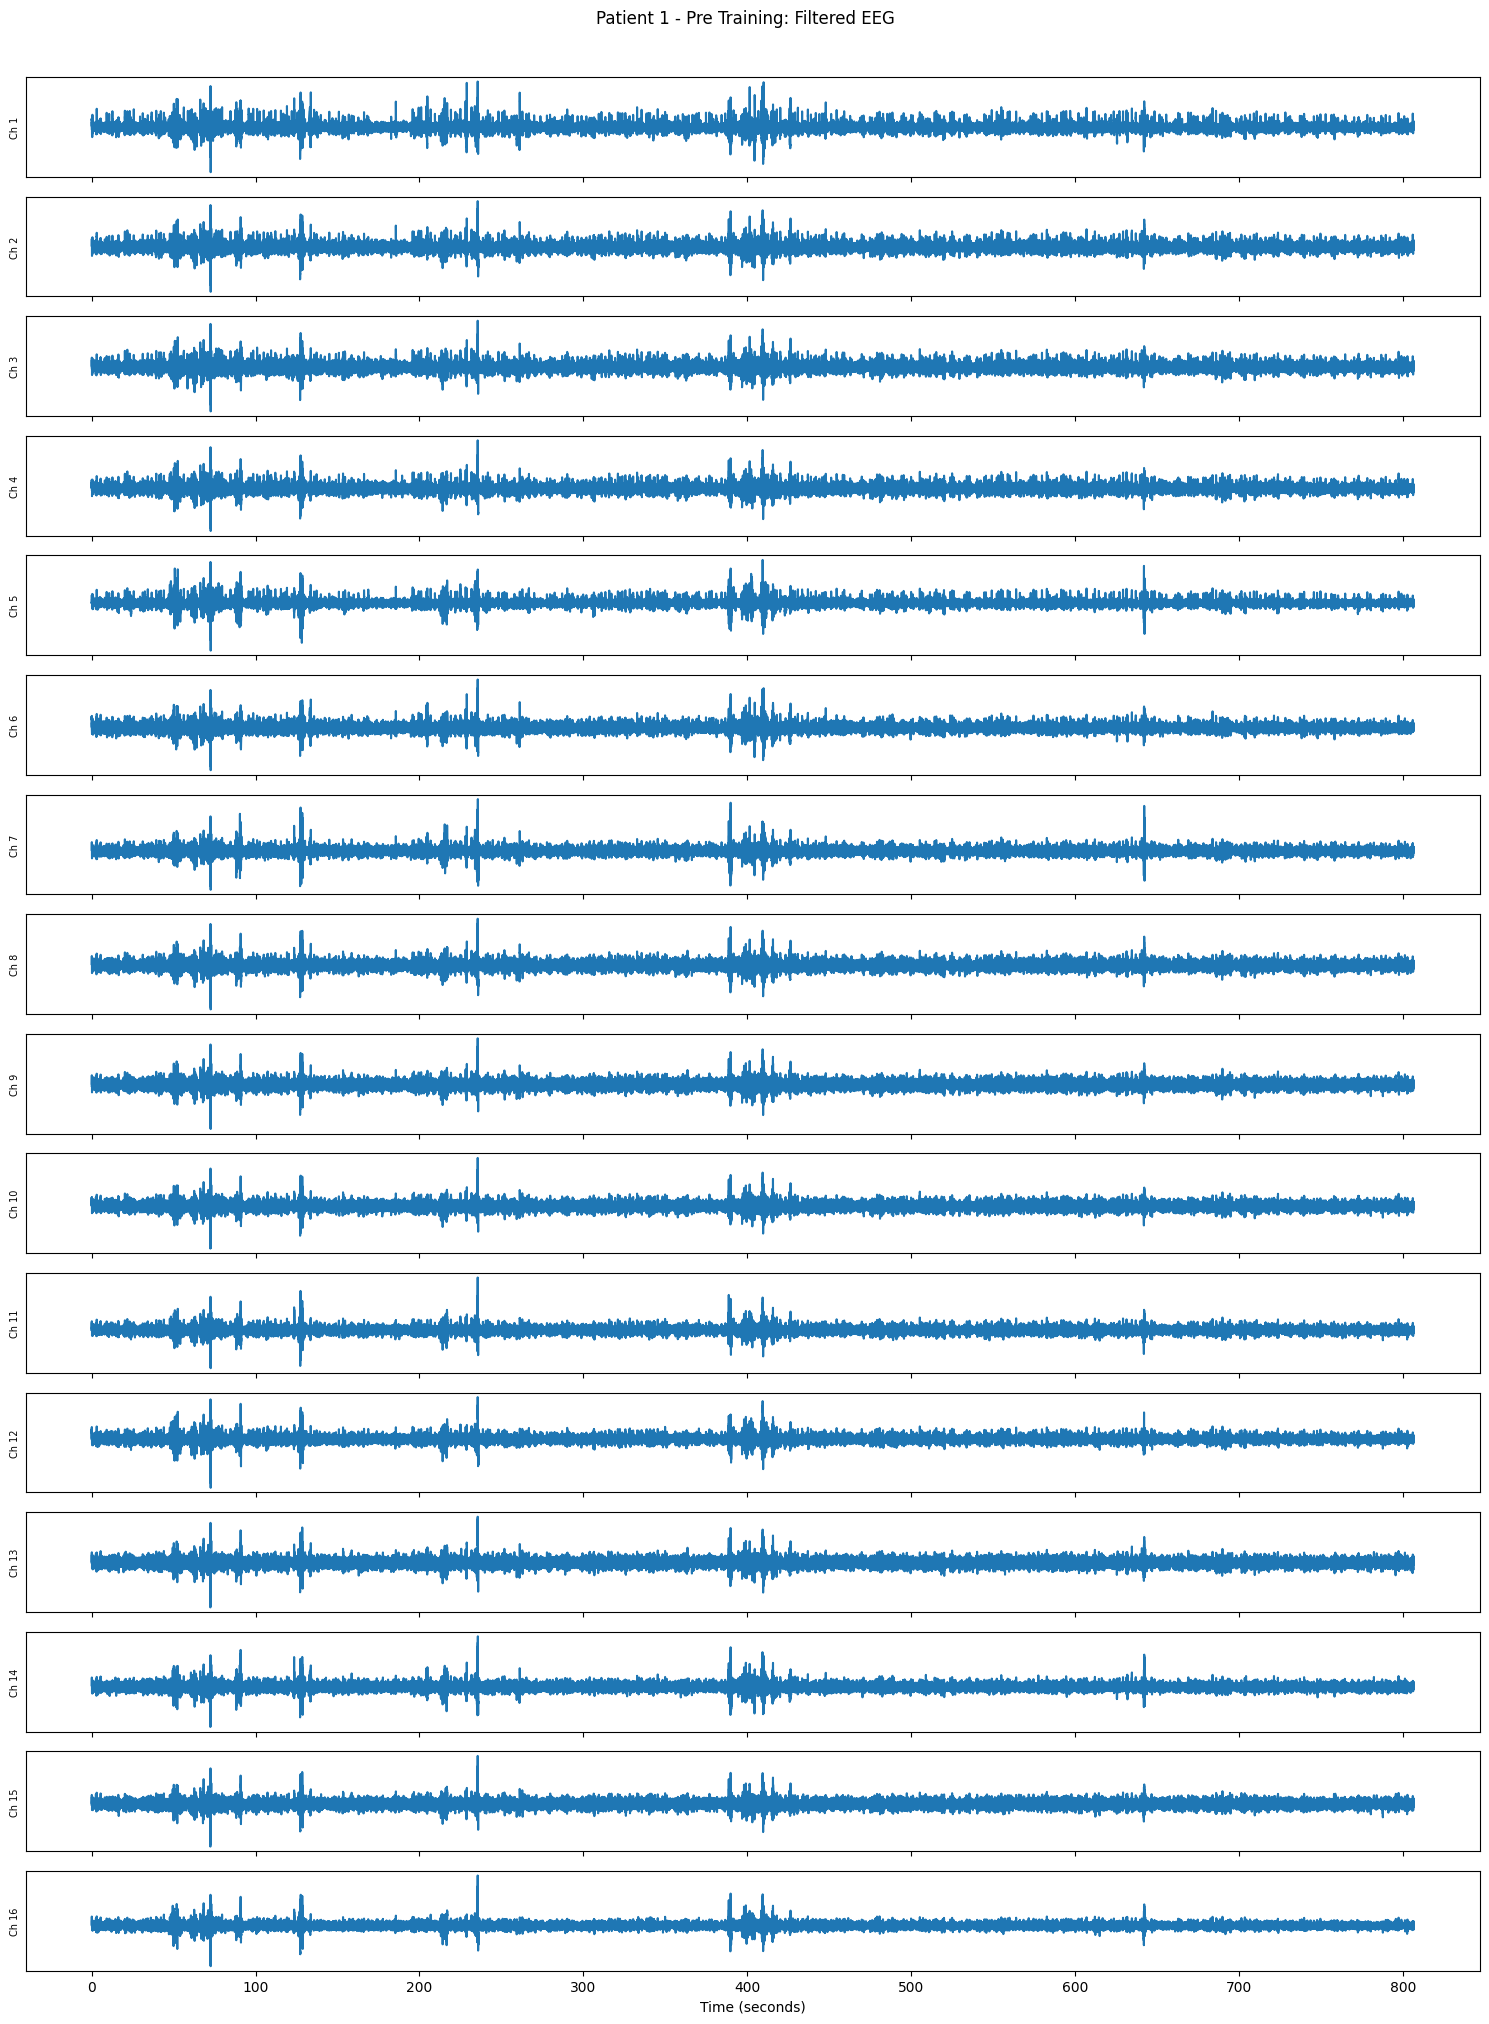

Plot saved!


ValueError: x and y must have same first dimension, but have shapes (206536,) and (0, 271816)

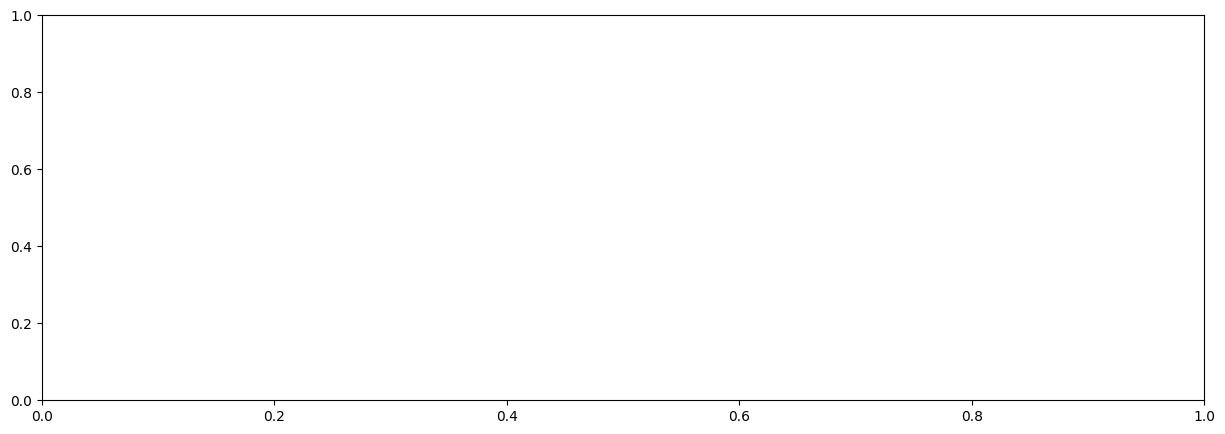

In [87]:
t_trimmed = np.arange(y_pre_training.shape[0]) / fs
t_trimmed = t_trimmed.flatten()  # Flatten the time array to 1D

print(f"Total duration in array: {t_trimmed[-1]} seconds")
print(f"Data shape: {y_pre_training_filtered.shape}")

fig, axes = plt.subplots(16, 1, figsize=(15, 20), sharex=True)

for i, ax in enumerate(axes):
    ax.plot(t_trimmed, y_pre_training_filtered[:, i])
    ax.set_ylabel(f'Ch {i+1}', fontsize=7)
    ax.set_yticks([])

plt.xlabel('Time (seconds)')
plt.suptitle('Patient 1 - Pre Training: Filtered EEG', y=1.01)
plt.tight_layout()
plt.savefig('P1_filtered_eeg.png')
plt.show()
print("Plot saved!")



fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(t_trimmed, trig_trimmed[0:,], color='red', lw=1.5)

ax.set_ylabel('Trigger Value (1=L, -1=R)', fontsize=10)
ax.set_xlabel('Time (seconds)', fontsize=10)
ax.set_title('Patient 1 - Pre Training: Trigger Times', fontsize=14)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('P1_triggers.png')
plt.show()

print("Trigger plot saved!")

In [ ]:
y_pre_training = trim_data(y_pre_training, fs, start_time=255)
trig_trimmed = trim_data(trig_pre_training[0:,], fs, start_time=255)


y_pre_training_filtered = notch_filter(y_pre_training, fs, notch_freq=50)  # Remove 50 Hz powerline noise
y_pre_training_filtered = notch_filter(y_pre_training, fs, notch_freq=60)  # Remove 60 Hz powerline noise
y_pre_training_filtered = bandpass_filter(y_pre_training_filtered, fs, lowcut=1, highcut=30, order=4)  # Keep frequencies between 1 and 30 Hz

np.savez('P1_PRE_training_cleaned.npz', 
         data=y_pre_training_filtered, 
         trig=trig_trimmed) # Make sure triggers are trimmed too!

print("Data saved as P1_PRE_training_cleaned.npz")

Data saved as P1_PRE_training_cleaned.npz


In [ ]:
import numpy as np

def epoch_data(data, trig, fs, time_after_before, total_time):
    for 
